# Project: BBLF AI Selector v2 
# Section: Model Pipeline - Expected Points Model
## Sub Section: Pre Tournament

Goal: Develop the most robust and predictive model to forecast the players' expected fantasy points for BBL15

Things to add:
2. LightGBM Model Pipeline
3. Separate Batting & Bowling Points Models
4. Standard Deviation Model
5. Improve scoring process/ data collection process - via chatgpt and web resources
6. Likelihood of selection model - basic model to identify pr of starting given current season behaviour (might not be feasible)

In [97]:
# pip install --upgrade scikit-learn xgboost interpret

# Prerequistes

In [98]:
# 0. Prerequistes

import pandas as pd
import numpy as np
import math
import os
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import (DecisionTreeRegressor, plot_tree, export_text)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor  
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
from statsmodels.api import OLS
import sklearn.model_selection as skm
from sklearn.model_selection import GridSearchCV 
import xgboost as xgb
from xgboost import XGBRegressor
import joblib

import warnings
warnings.filterwarnings("ignore")

  # Interpret
import interpret
from interpret import show
from interpret.data import Marginal
from interpret.glassbox import ExplainableBoostingRegressor

os.getcwd()
directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/python_script/pre-season/'
# add_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Big Bash Fantasy AI/data/add_data_created/round_9'
# over_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Big Bash Fantasy AI/data/add_data_created/overall'
py_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/data/python_data/'

# Data Extraction

In [99]:
# 1. Data Extraction 
# Pull in model_data csv file 

model_df = pd.read_csv(os.path.join(py_data_directory,'bblf_v2_model_data_v3_bowl.csv'), low_memory=False)

# model_df["Home_f"] = model_df["Home_f"].astype(str)
# model_df["Home_f"] = model_df["Home_f"].astype(object)
# model_df.loc[:,"opp_Adelaide Strikers":"Home_Hobart Hurricanes"] = model_df.loc[:,"opp_Adelaide Strikers":"Home_Hobart Hurricanes"].astype(object)

# Rename response variable for easy reference
if 'resp_var_bowl' in model_df.columns:    
    model_df = model_df.rename(columns={"resp_var_bowl":"resp_var"})
    print("Response variable changed to correct format")
elif 'resp_var_bat' in model_df.columns:
    model_df = model_df.rename(columns={"resp_var_bat":"resp_var"})
    print("Response variable changed to correct format")
else:
    print("Response variable already correct format")

# Create dataframe with NA values removed
model_df_NA_rm = model_df.dropna()
len(model_df_NA_rm)

Response variable changed to correct format


289

# Pipeline Parameters

In [100]:
save_mdl = True  # Set to True to save model object
model_name = "ps_bwl_mdl_1"  # Pipeline model name

# Feature Selection

In [101]:
# 2. Feature Selection
    # Dropping Columns & Create Split Data prior to modelling
col_names = model_df.columns
print (col_names)

# other_var_drop = ["resp_var", "Unnamed: 0","season", "player", "team", "match_id"]
other_var_drop = ["resp_var", "Unnamed: 0","season", "player"]
# bowler feat_drop
feat_drop = ["max_season_overs_lag3",
            "max_season_fp_ebg_lag1",
            "sd_season_dots_lag1",
            "avg_season_fp_ebg_lag1",
            "avg_season_extras_lag1",
            "sd_season_fp_bowl_lag1",
            "sd_season_overs_lag3",
            "avg_season_wick_lag3",
            "sd_season_wick_lag3",
            "min_season_overs_lag3",
            "max_season_overs_lag1",
            "max_season_wick_lag1",
            "sd_season_fp_bowl_lag3",
            "sd_season_dots_lag3",
            "sd_season_fp_ebg_lag2",
            "avg_season_extras_lag2",
            "sd_season_wick_lag1",
            "avg_season_econ_lag2",
            "min_season_extras_lag3",
            "min_season_overs_lag2",
            "min_season_overs_lag1",
            "avg_season_fp_ebg_lag2",
            "max_season_wick_lag3",
            "max_season_extras_lag1",
            "max_season_econ_lag1",
            "min_season_wick_lag1",
            "min_season_extras_lag1",
            "min_season_wick_lag2",
            "min_season_econ_lag1",
            "max_season_overs_lag2",
            "min_season_extras_lag2",
            "min_season_econ_lag2",
            "min_season_fp_ebg_lag3",
            "min_season_econ_lag3",
            "sd_season_extras_lag1",
            "avg_season_fp_ebg_lag3",
            "sd_season_econ_lag1",
            "max_season_fp_ebg_lag3",
            "avg_season_wick_lag1",
            "max_season_fp_bowl_lag1",
            "avg_season_fp_wbg_lag1",
            "sd_season_fp_ebg_lag3",
            "avg_season_overs_lag3",
            "max_season_dots_lag1",
            "sd_season_fp_ebg_lag1",
            "min_season_dots_lag2",
            "sd_season_fp_bowl_lag2",
            "max_season_dots_lag3",
            "sd_season_overs_lag1",
            "sd_season_econ_lag3",
            "avg_season_dots_lag3",
            "avg_season_econ_lag1",
            "sd_season_extras_lag3",
            "max_season_fp_ebg_lag2",
            "min_season_fp_ebg_lag1",
            "min_season_wick_lag3",
            "avg_season_fp_wbg_lag3",
            "max_season_econ_lag2",
            "sd_season_econ_lag2",
            "avg_season_econ_lag3",
            "max_season_extras_lag3",
            "min_season_fp_bowl_lag3",
            "avg_season_extras_lag3",
            "max_season_econ_lag3",
            "min_season_fp_ebg_lag2",
            "avg_season_fp_wbg_lag2",
            "avg_season_wick_lag2",
            "max_season_wick_lag2",
            "sd_season_dots_lag2",
            "min_season_dots_lag3",
            "sd_season_overs_lag2",
            "min_season_dots_lag1",
            "max_season_extras_lag2",
            "min_season_fp_bowl_lag2",
            "max_season_fp_bowl_lag3",
            "sd_season_wick_lag2",
            "sd_season_extras_lag2"]
# batting feat_drop
# feat_drop = ["max_season_fp_srg_lag1",
#             "min_season_strike_lag2",
#             "max_season_fp_bat_lag3",
#             "max_season_fp_bat_lag2",
#             "avg_season_fp_srg_lag1",
#             "max_season_strike_lag1",
#             "avg_season_strike_lag3",
#             "avg_season_fp_srg_lag2",
#             "sd_season_strike_lag3",
#             "sd_season_runs_lag3",
#             "min_season_fp_bat_lag1",
#             "sd_season_strike_lag1",
#             "avg_season_strike_lag1",
#             "avg_season_strike_lag2",
#             "max_season_fp_srg_lag3",
#             "sd_season_fp_srg_lag1",
#             "max_season_strike_lag3",
#             "avg_season_strike_lag1",
#             "avg_season_fp_srg_lag3",
#             "min_season_runs_lag3",
#             "min_season_runs_lag1",
#             "min_season_strike_lag1",
#             "sd_season_fp_srg_lag2",
#             "min_season_fp_srg_lag2",
#             "sd_season_fp_srg_lag3",
#             "min_season_strike_lag3",
#             "max_season_strike_lag2",
#             "max_season_fp_srg_lag2",
#             "min_season_fp_srg_lag1",
#             "min_season_fp_srg_lag3",
#             "sd_season_fp_bat_lag3",
#             "sd_season_strike_lag2",
#             "max_season_runs_lag3",
#             "max_season_runs_lag2",
#             "sd_season_runs_lag1",
#             "avg_season_runs_lag3",
#             "max_season_runs_lag1",
#             "min_season_runs_lag2",
#             "min_season_fp_bat_lag3",
#             "avg_season_fp_rbg_lag1",
#             "avg_season_runs_lag2",
#             "sd_season_runs_lag2",
#             "sd_season_fp_bat_lag2",
#             "min_season_fp_bat_lag2",
#             "avg_season_fp_sre_lag3",
#             "avg_season_runs_lag1",
#             "max_season_fp_bat_lag1",
#             "avg_season_fp_bat_lag3"]

# total point feat_drop
# feat_drop = [
#             "min_season_extras_lag3",
#             "max_season_econ_lag3",
#             "min_season_econ_lag3",
#             "sd_season_fp_srg_lag2",
#             "avg_season_wick_lag2",
#             "avg_season_dots_lag3",
#             "sd_season_econ_lag1",
#             "sd_season_fp_srg_lag3",
#             "sd_season_strike_lag1",
#             "max_season_dots_lag3",
#             "avg_season_fp_ere_lag3",
#             "min_season_dots_lag3",
#             "min_season_fp_ebg_lag1",
#             "min_season_fp_srg_lag1",
#             "max_season_fp_srg_lag1",
#             "min_season_overs_lag1",
#             "max_season_wick_lag1",
#             "min_season_econ_lag1",
#             "min_season_extras_lag1",
#             "max_season_econ_lag1",
#             "min_season_wick_lag2",
#             "max_season_overs_lag2",
#             "min_season_fp_srg_lag2",
#             "min_season_wick_lag3",
#             "max_season_econ_lag2",
#             "min_season_econ_lag2",
#             "min_season_fp_ebg_lag3",
#             "min_season_overs_lag3",
#             "min_season_fp_srg_lag3",
#             "max_season_wick_lag3",
#             "max_season_fp_bat_lag3",
#             "avg_season_fp_ebg_lag3",
#             "avg_season_extras_lag2",
#             "max_season_fp_ebg_lag1",
#             "min_season_dots_lag1",
#             "max_season_strike_lag2",
#             "min_season_fp_ebg_lag2",
#             "sd_season_fp_ebg_lag3",
#             "min_season_fp_bowl_lag2",
#             "max_season_runs_lag3",
#             "avg_season_wick_lag3",
#             "avg_season_fp_srg_lag2",
#             "min_season_strike_lag2",
#             "avg_season_overs_lag2",
#             "min_season_dots_lag2",
#             "sd_season_strike_lag2",
#             "max_season_extras_lag1",
#             "min_season_fp_bowl_lag3",
#             "min_season_runs_lag1",
#             "avg_season_fp_wbg_lag1",
#             "max_season_overs_lag3",
#             "min_season_wick_lag1",
#             "min_season_extras_lag2",
#             "min_season_overs_lag2",
#             "max_season_overs_lag1",
#             "sd_season_fp_bat_lag3",
#             "max_season_fp_srg_lag2",
#             "min_season_fp_bat_lag1",
#             "avg_season_fp_wbg_lag2",
#             "avg_season_fp_wbg_lag3",
#             "sd_season_strike_lag3",
#             "avg_season_extras_lag3",
#             "min_season_strike_lag1",
#             "avg_season_fp_rbg_lag3",
#             "max_season_strike_lag3",
#             "avg_season_overs_lag3",
#             "sd_season_fp_ebg_lag2",
#             "avg_season_dots_lag2",
#             "sd_season_extras_lag2",
#             "avg_season_extras_lag1",
#             "avg_season_overs_lag1",
#             "sd_season_strike_lag1",
#             "avg_season_strike_lag2",
#             "min_season_strike_lag3",
#             "avg_season_extras_lag3",
#             "max_season_extras_lag3",
#             "max_season_wick_lag2",
#             "avg_season_fp_bowl_lag3",
#             "avg_season_runs_lag2",
#             "min_season_runs_lag2",
#             "max_season_fp_ebg_lag1",
#             "avg_season_fp_ebg_lag1",
#             "sd_season_dots_lag3",
#             "sd_season_overs_lag3",
#             "sd_season_fp_bowl_lag3",
#             "max_season_fp_srg_lag3",
#             "avg_season_wick_lag1",
#             "max_season_fp_ebg_lag2",
#             "min_season_fp_bat_lag3",
#             "avg_season_strike_lag3",
#             "avg_season_fp_srg_lag3",
#             "avg_season_econ_lag1",
#             "max_season_fp_bowl_lag2",
#             "sd_season_dots_lag2",
#             "max_season_runs_lag2",
#             "sd_season_wick_lag3",
#             "sd_season_fp_srg_lag1",
#             "avg_season_fp_ebg_lag2",
#             "avg_season_econ_lag3",
#             "max_season_strike_lag1",
#             "avg_season_fp_ere_lag2",
#             "avg_season_econ_lag2",
#             "min_season_runs_lag3",
#             "sd_season_extras_lag3",
#             "sd_season_fp_ebg_lag1",
#             "min_season_fp_lag2",
#             "min_season_fp_lag3",
#             "sd_season_econ_lag3",
#             "min_season_fp_bat_lag2",
#             "sd_season_runs_lag3",
#             "sd_season_overs_lag2",
#             "sd_season_fp_lag2",
#             "max_season_fp_ebg_lag3",
#             "avg_season_strike_lag1",
#             "sd_season_runs_lag2",
#             "sd_season_fp_bat_lag2",
#             "max_season_dots_lag2",
#             "max_season_extras_lag2",
#             "avg_season_fp_sre_lag1",
#             "avg_season_fp_sre_lag2",
#             "max_season_fp_bowl_lag3"
#             ]

print(feat_drop)

# Drop unneeded columns
model_df = model_df.drop(feat_drop, axis = 1)
len(model_df)

X = model_df.drop(other_var_drop, axis = 1)
Y = model_df["resp_var"]


print(X.dtypes)

# NA removed data
X_na_rm = model_df_NA_rm.drop(other_var_drop, axis = 1)
X_na_rm = X_na_rm.drop(feat_drop, axis = 1)
Y_na_rm = model_df_NA_rm["resp_var"]



Index(['Unnamed: 0', 'player', 'season', 'resp_var', 'avg_season_fp_bowl_lag1',
       'max_season_fp_bowl_lag1', 'min_season_fp_bowl_lag1',
       'sd_season_fp_bowl_lag1', 'avg_season_fp_ere_lag1',
       'avg_season_fp_ebg_lag1', 'max_season_fp_ebg_lag1',
       'min_season_fp_ebg_lag1', 'sd_season_fp_ebg_lag1',
       'avg_season_fp_wbg_lag1', 'avg_season_overs_lag1',
       'max_season_overs_lag1', 'min_season_overs_lag1',
       'sd_season_overs_lag1', 'avg_season_wick_lag1', 'max_season_wick_lag1',
       'min_season_wick_lag1', 'sd_season_wick_lag1', 'avg_season_dots_lag1',
       'max_season_dots_lag1', 'min_season_dots_lag1', 'sd_season_dots_lag1',
       'avg_season_extras_lag1', 'max_season_extras_lag1',
       'min_season_extras_lag1', 'sd_season_extras_lag1',
       'avg_season_econ_lag1', 'max_season_econ_lag1', 'min_season_econ_lag1',
       'sd_season_econ_lag1', 'avg_season_fp_bowl_lag2',
       'max_season_fp_bowl_lag2', 'min_season_fp_bowl_lag2',
       'sd_season_f

# Train/ Test Split

In [102]:
# 3. Train/ Test Split

seed = 17

np.random.seed(seed)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=seed)

names = list(X_train)

X_train_na_rm, X_test_na_rm, Y_train_na_rm, Y_test_na_rm = train_test_split(X_na_rm, Y_na_rm, test_size=0.01, random_state=seed)


# EDA

In [103]:
# EDA 
# marginal = Marginal(names).explain_data(X_train_na_rm, Y_train_na_rm, name='Train Data')
# show(marginal)



# Model Builder

In [104]:
# 4. Model Build
# 4.0. Model Type Options: a. Linear Regression; b. Decision Tree; c. Random Forest, d. Bagging e. EBM f. GBM g. XGBoost

Model_Type = "XGBoost"
print(Model_Type)

cv_splits = 5
# Hyperparameter Grid
param_grid = { 
    'n_estimators': [2500], 
    # 'max_features': ['sqrt'], 
    'max_depth': [2], 

    # For Boosting models
    'learning_rate': [0.001], # 0.01 - 0.3
    'min_child_weight': [6], # 1 - 10
    'subsample': [0.5], # 0.5 - 1.0
    'colsample_bytree': [0.5], # 0.5 - 1.0
    'gamma': [10], # 0 - 10
}

XGBoost


In [105]:
# 4a. Linear Regression
if Model_Type == "Linear Regression":
    # Model Object
    model_obj = LinearRegression(fit_intercept = True).fit(X_train_na_rm, Y_train_na_rm)
    #print("Model Coefficients:", model_obj.coef_)
    #print("Model Intercept:", model_obj.coef_)
    X_train_OLS = sm.add_constant(X_train_na_rm).astype(float)
    print(OLS(Y_train,X_train_OLS).fit().summary())

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)
    
else:
  print("Note: To create Linear Regression Model change Model Type")

    
# 4b. Decision Tree
if Model_Type == "Decision Tree":
    # Model Object
    model_obj = tree.DecisionTreeRegressor(max_depth = 3).fit(X_train, Y_train)

    # Tree Rules
    rules = tree.export_text(model_obj, feature_names = names)
    print(rules)

    tree.plot_tree(model_obj, feature_names = names, filled = True)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)

else:
  print("Note: To create Decision Tree Model change Model Type")

# 4c. Random Forest
if Model_Type == "Random Forest":
    
    # Grid Search
    gs = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, verbose = 3, cv=cv_splits) 
    gs.fit(X_train, Y_train) 
    print(gs.best_estimator_) 
    
    # Model Object     
    model_obj = RandomForestRegressor(n_estimators=gs.best_estimator_.n_estimators,
                                      max_features = gs.best_estimator_.max_features,
                                      max_depth=gs.best_estimator_.max_depth,
                                      random_state=0,
                                      oob_score=True).fit(X_train, Y_train)
    print(model_obj.get_params())
  
    #model_obj = RandomForestRegressor(max_features = "sqrt",
    #                                  n_estimators=2000,
    #                                  random_state=0,
    #                                  #max_depth=10,
    #                                  oob_score=True).fit(X_train, Y_train)
    #print(model_obj.get_params())
  
    # Train Pred
    Y_pred_train = model_obj.predict(X_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 

    # Model Type 
    print(Model_Type)
    
    # Feature List
    print(X_train.columns)
    max_feat = round(math.sqrt(len(X_train.columns)))
    print(max_feat)   

    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)
    
else:
  print("Note: To create Random Forest Model change Model Type")

# 4d. Bagging
if Model_Type == "Bagging":
    # Model Object
    model_obj = RandomForestRegressor(max_features=X_train.shape[1], n_estimators=5000, random_state=0).fit(X_train, Y_train)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)
    
    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)

else:
  print("Note: To create Bagging Model change Model Type")

# 4e. EBM
if Model_Type == "EBM":
    # Model Object
    model_obj = ExplainableBoostingRegressor(names, interactions=0).fit(X_train, Y_train)

    # Global Performance
    ebm_global = model_obj.explain_global(name='EBM')
    show(ebm_global)

    # Local Performance
    ebm_local = model_obj.explain_local(X_test, Y_test, name='EBM')
    show(ebm_local, 0)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)

else:
  print("Note: To create EBM change Model Type")

# 4f. Boosting
if Model_Type == "GBM":

    # Grid Search
    gs = GridSearchCV(GradientBoostingRegressor(), param_grid=param_grid, verbose = 3, cv=cv_splits) 
    gs.fit(X_train, Y_train) 
    print(gs.best_estimator_) 
    
    # Model Object     
    model_obj = GradientBoostingRegressor(n_estimators=gs.best_estimator_.n_estimators,
                                          learning_rate= gs.best_estimator_.learning_rate,
                                          max_depth=gs.best_estimator_.max_depth,
                                          random_state=0).fit(X_train, Y_train)
    print(model_obj.get_params())

    # Model Object
    #model_obj = GradientBoostingRegressor(n_estimators = 5000, learning_rate = 0.001, max_depth = 2, random_state=0).fit(X_train, Y_train)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)

    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)

else:
  print("Note: To create GBM change Model Type")

# 4g. XGBoost
if Model_Type == "XGBoost":
    # Grid Search
    gs = GridSearchCV(XGBRegressor(n_jobs=1), param_grid=param_grid, verbose = 3, cv = cv_splits, n_jobs=None) 
    gs.fit(X_train, Y_train)
    print(gs.best_estimator_) 
    
    # Model Object     
    model_obj = XGBRegressor(n_estimators=gs.best_estimator_.n_estimators,
                            max_depth=gs.best_estimator_.max_depth,
                            learning_rate= gs.best_estimator_.learning_rate,
                            min_child_weight= gs.best_estimator_.min_child_weight,
                            subsample= gs.best_estimator_.subsample,
                            colsample_bytree= gs.best_estimator_.colsample_bytree,
                            gamma= gs.best_estimator_.gamma,
                            random_state=0,
                            oob_score=True).fit(X_train, Y_train)
    print(model_obj.get_params())

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 

    # Model Type 
    print(Model_Type)
    
    # Feature List
    print(X_train.columns)
    max_feat = round(math.sqrt(len(X_train.columns)))
    print(max_feat)   

    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)

else:
  print("Note: To create XGB change Model Type")    


Note: To create Linear Regression Model change Model Type
Note: To create Decision Tree Model change Model Type
Note: To create Random Forest Model change Model Type
Note: To create Bagging Model change Model Type
Note: To create EBM change Model Type
Note: To create GBM change Model Type
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END colsample_bytree=0.5, gamma=10, learning_rate=0.001, max_depth=2, min_child_weight=6, n_estimators=2500, subsample=0.5;, score=0.258 total time=   0.2s
[CV 2/5] END colsample_bytree=0.5, gamma=10, learning_rate=0.001, max_depth=2, min_child_weight=6, n_estimators=2500, subsample=0.5;, score=0.314 total time=   0.2s
[CV 3/5] END colsample_bytree=0.5, gamma=10, learning_rate=0.001, max_depth=2, min_child_weight=6, n_estimators=2500, subsample=0.5;, score=0.152 total time=   0.2s
[CV 4/5] END colsample_bytree=0.5, gamma=10, learning_rate=0.001, max_depth=2, min_child_weight=6, n_estimators=2500, subsample=0.5;, score=0.291 total time

MAE - Train: 10.678899453925391
MAPE - Train: 1.0607574235831911
RMSE - Train: 13.72524287673097
R2 - Train: 0.34174641475286993


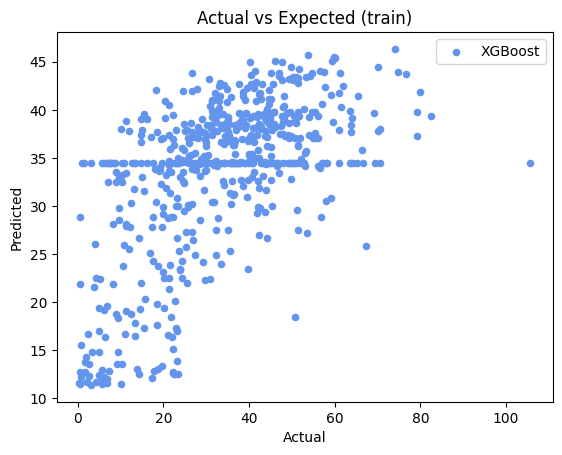

MAE - Test: 9.72818778365883
MAPE - Test: 0.43381565178738446
RMSE - Test: 12.51616048434651
R2 - Test: 0.28527750368233784


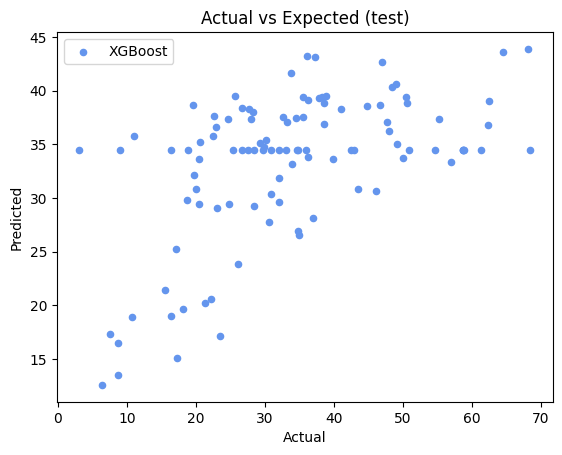

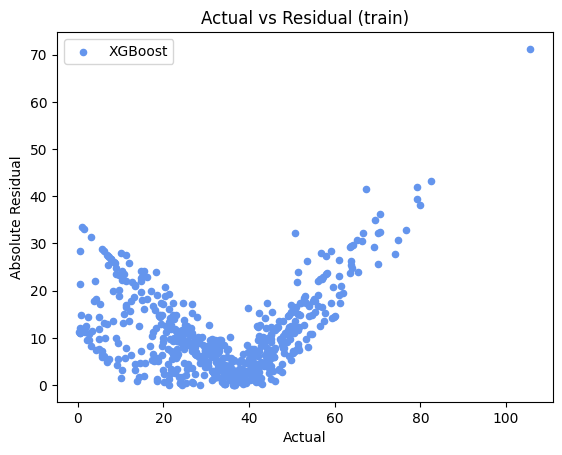

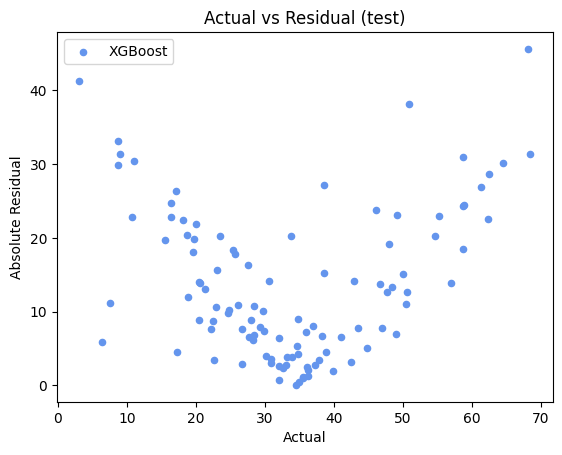

In [106]:
# 5. Model Performance

# 5a. Train Performance Metrics
 
mae_train = mean_absolute_error(y_true = Y_train, y_pred = Y_pred_train)
mape_train = mean_absolute_percentage_error(y_true = Y_train, y_pred = Y_pred_train) 
rmse_train = root_mean_squared_error(y_true = Y_train, y_pred = Y_pred_train) 
r2_train = r2_score(y_true = Y_train, y_pred = Y_pred_train)

print("MAE - Train:", mae_train) 
print("MAPE - Train:", mape_train) 
print("RMSE - Train:", rmse_train)
print("R2 - Train:", r2_train)

  # Actual vs Expected Plots

plt.figure()
plt.scatter(Y_train, Y_pred_train, s = 20, color="cornflowerblue", label=Model_Type)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (train)")
# plt.plot([0, 0], [250, 250], 'k-')
plt.legend()
plt.show()

# 5b. Test Performance Metrics

mae_test = mean_absolute_error(y_true = Y_test, y_pred = Y_pred_test) 
mape_test = mean_absolute_percentage_error(y_true = Y_test, y_pred = Y_pred_test) 
rmse_test = root_mean_squared_error(y_true = Y_test, y_pred = Y_pred_test) 
r2_test = r2_score(y_true = Y_test, y_pred = Y_pred_test)

print("MAE - Test:", mae_test)
print("MAPE - Test:", mape_test)
print("RMSE - Test:", rmse_test)
print("R2 - Test:", r2_test)

  # Actual vs Expected Plots

plt.figure()
plt.scatter(Y_test, Y_pred_test, s = 20, color="cornflowerblue", label= Model_Type)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (test)")
plt.legend()
plt.show()

# 5c. Residual Analysis
  # Train Residuals
Y_train_res = pd.DataFrame(Y_train).reset_index(drop=True)
Y_train_pred = pd.DataFrame(Y_pred_train).reset_index(drop=True)
Y_train_res['pred'] = Y_train_pred[0]
Y_train_res['res'] = Y_train_res['resp_var'] - Y_train_res['pred']
Y_train_res['abs_res'] = abs(Y_train_res['res'])
train_res = pd.concat([Y_train_res, X_train.reset_index(drop=True)], axis=1)

  # Test Residuals
Y_test_res = pd.DataFrame(Y_test).reset_index(drop=True)
Y_test_pred = pd.DataFrame(Y_pred_test).reset_index(drop=True)
Y_test_res['pred'] = Y_test_pred[0]
Y_test_res['res'] = Y_test_res['resp_var'] - Y_train_res['pred']
Y_test_res['abs_res'] = abs(Y_test_res['res'])
test_res = pd.concat([Y_test_res, X_test.reset_index(drop=True)], axis=1)

  # Plots
plt.figure()
plt.scatter(train_res['resp_var'], train_res['abs_res'], s = 20, color="cornflowerblue", label= Model_Type)
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Residual (train)")
plt.legend()
plt.show()


plt.figure()
plt.scatter(test_res['resp_var'], test_res['abs_res'], s = 20, color="cornflowerblue", label= Model_Type)
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Residual (test)")
plt.legend()
plt.show()

# Model Scoring for Current Players

In [107]:
# Save model object
if save_mdl:
    joblib.dump(model_obj, f'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/python_script/pre-season/models/{model_name}')
    print(f'Saved {Model_Type} model object as {model_name}')
# fant_model_df.to_csv(os.path.join(directory,'python_data/bblf_v2_model_data.csv'))
# model_obj = joblib.load('C:/Users/dilan/OneDrive/Documents/Data Science Projects/Big Bash Fantasy AI/model/dur_tourny_model_rnd7_19')
# feature_imp = pd.DataFrame(
# {'importance':model_obj.feature_importances_},
# index=names)
# feature_imp = feature_imp.sort_values(by='importance', ascending=False)
# print(feature_imp)


Saved XGBoost model object as ps_bwl_mdl_1


In [108]:
# # 6. Use Model Object to calculate the number of points for each current player for each gameweek
#     # 6a. Data Extraction of BBL 14 Data

# # Data Extract to change each round
# team_rank_14_df = pd.read_csv(os.path.join(add_data_directory,'team_season_rank_rnd_9.csv'), low_memory=False)
# bbl14_prior_df = pd.read_csv(os.path.join(add_data_directory,'player_bbl14_pts_rnd_9.csv'), low_memory=False)
# player_over_bowl_df = pd.read_csv(os.path.join(add_data_directory,'player_over_ball_rnd_9.csv'), low_memory=False)
# player_bat_pos_df = pd.read_csv(os.path.join(add_data_directory,'player_bat_pos_rnd_9.csv'), low_memory=False)

# # BBL 14 Player & their Team Data

# player_df = pd.read_csv(os.path.join(py_data_directory,'player_price.csv'), low_memory=False)
# player_df = player_df[["Full_Name","player", "Team"]].rename(columns = {"Full_Name":"Name"})
# print(player_df)

# # BBL 14 Player Features
#     # Lags
# lags_14_df = pd.read_csv(os.path.join(py_data_directory,'bbl14_lags.csv'), low_memory=False)
# lags_14_df = lags_14_df.drop(["Unnamed: 0"], axis = 1)
# print(lags_14_df)

# # BBL14 Fixture
#     ## Need a table of for each team which opposition and where they play against the opposition

# team_venue_df = pd.read_csv(os.path.join(over_data_directory,'team_loc_fixture.csv'), low_memory=False)
# print(team_venue_df)

# ## Join BBL14 Player Team Data - All Player Fixture Possible Scenarios
# player_fix_scen_df = pd.merge(player_df , team_venue_df, left_on = ["Team"], right_on = ["Team"], how = "left")
# player_fix_scen_df = player_fix_scen_df.rename(columns = {"Opposition":"opp", "Venue":"venue"})
# print(player_fix_scen_df)

# ## Join BBL14 Player Feature Data - All Player Fixture Possible Scenarios
# bbl14_scen_df = pd.merge(player_fix_scen_df , lags_14_df, left_on = ["player"], right_on = ["player"], how = "left")
# print(bbl14_scen_df)

# unique_play_fix = player_fix_scen_df['player'].unique()
# print(unique_play_fix)

# unique_lag = lags_14_df['player'].unique()
# print(unique_lag)

# # BBL14 Rank Data
# team_rank_14_df = team_rank_14_df[team_rank_14_df["season"] == 14].rename(columns = {"team":"opp"})
# print(team_rank_14_df)

# bbl14_scen_df = pd.merge(bbl14_scen_df , team_rank_14_df, left_on = ["opp"], right_on = ["opp"], how = "left")
# bbl14_scen_df['Opposition'] = bbl14_scen_df['opp'].copy()
# bbl14_scen_df['Venue'] = bbl14_scen_df['venue'].copy()

# # One Hot Encoding
# bbl14_play_scen_df = pd.get_dummies(bbl14_scen_df, columns= ['opp','venue','rank_group'])

# bbl14_play_scen_df.loc[:,"opp_Adelaide Strikers":"opp_Sydney Thunder"] = bbl14_play_scen_df.loc[:,"opp_Adelaide Strikers":"opp_Sydney Thunder"].astype(int)
# bbl14_play_scen_df.loc[:,"opp_Adelaide Strikers":"opp_Sydney Thunder"] = bbl14_play_scen_df.loc[:,"opp_Adelaide Strikers":"opp_Sydney Thunder"].astype(object)

# bbl14_play_scen_df.loc[:,"venue_Adelaide Oval":"venue_Sydney Showground"] = bbl14_play_scen_df.loc[:,"venue_Adelaide Oval":"venue_Sydney Showground"].astype(int)
# bbl14_play_scen_df.loc[:,"venue_Adelaide Oval":"venue_Sydney Showground"] = bbl14_play_scen_df.loc[:,"venue_Adelaide Oval":"venue_Sydney Showground"].astype(object)

# bbl14_play_scen_df.loc[:,"rank_group_High":"rank_group_Middle"] = bbl14_play_scen_df.loc[:,"rank_group_High":"rank_group_Middle"].astype(int)
# bbl14_play_scen_df.loc[:,"rank_group_High":"rank_group_Middle"] = bbl14_play_scen_df.loc[:,"rank_group_High":"rank_group_Middle"].astype(object)

# # Interaction Terms
# # Venue & Home Flag (See if the certain teams have bigger home ground advantage)
# bbl14_play_scen_df["Home_Adelaide Strikers"] = np.where((bbl14_play_scen_df["venue_Adelaide Oval"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Melbourne Stars"] = np.where((bbl14_play_scen_df["venue_Melbourne Cricket Ground"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Melbourne Renegades"] = np.where((bbl14_play_scen_df["venue_Marvel"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Brisbane Heat"] = np.where((bbl14_play_scen_df["venue_GABBA"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Perth Scorchers"] = np.where((bbl14_play_scen_df["venue_Perth Stadium"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Sydney Sixers"] = np.where((bbl14_play_scen_df["venue_SCG"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Sydney Thunder"] = np.where((bbl14_play_scen_df["venue_Sydney Showground"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)
# bbl14_play_scen_df["Home_Hobart Hurricanes"] = np.where((bbl14_play_scen_df["venue_Hobart"] == 1) & (bbl14_play_scen_df["Home_f"] == 1) , 1 , 0)

# bbl14_play_scen_df.loc[:,"Home_Adelaide Strikers":"Home_Hobart Hurricanes"] = bbl14_play_scen_df.loc[:,"Home_Adelaide Strikers":"Home_Hobart Hurricanes"].astype(object)

# print(bbl14_play_scen_df)

# # BBL 14 Prior Tournament Features
#     # Data Extract
# bbl14_prior_df = bbl14_prior_df.drop(['Team','Price'], axis = 1)
# bbl14_prior_df.columns = bbl14_prior_df.columns.str.replace(r'Game_', '')
# bbl14_prior_df = pd.melt(bbl14_prior_df, id_vars=['player'], value_vars= ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'],
#                          var_name='Game', value_name='fantasy_point').dropna()

#     # Previous Game
# bbl14_prev_game_df = bbl14_prior_df[["player", "Game"]].sort_values(by = ['player','Game']).drop_duplicates(subset = ["player"], keep='last')
# bbl14_prev_game_df = pd.merge(bbl14_prev_game_df, bbl14_prior_df, left_on = ["player", "Game"], right_on = ["player", "Game"], how = "left" )
# bbl14_prev_game_df = bbl14_prev_game_df.rename(columns = {"fantasy_point":"prev_game_fp"})

# bbl14_play_scen_df = pd.merge(bbl14_play_scen_df , bbl14_prev_game_df, left_on = ["player"], right_on = ["player"], how = "left")

#     # Last 2 Games
# bbl14_prev_2g_df = bbl14_prior_df.rename(columns = {"fantasy_point":"last_2g_fp"})
# bbl14_prev_2g_df = pd.merge(bbl14_prev_2g_df, bbl14_prev_game_df, left_on = ["player", "Game"], right_on = ["player", "Game"], how = "left")
# bbl14_prev_2g_df["drop_col"] = np.where(bbl14_prev_2g_df["prev_game_fp"]>= 0, 1, 0) 
# bbl14_prev_2g_df = bbl14_prev_2g_df[bbl14_prev_2g_df.drop_col == 0]
# bbl14_prev_2g_df = bbl14_prev_2g_df[["player", "Game"]].sort_values(by = ['player','Game']).drop_duplicates(subset = ["player"], keep='last')
# bbl14_prev_2g_df = pd.concat([bbl14_prev_2g_df[["player", "Game"]], bbl14_prev_game_df[["player", "Game"]]])
# bbl14_prev_2g_df = pd.merge(bbl14_prev_2g_df, bbl14_prior_df, left_on = ["player", "Game"], right_on = ["player", "Game"], how = "left" )
# bbl14_prev_2g_df = bbl14_prev_2g_df.rename(columns = {"fantasy_point":"last_2g_fp"})

# bbl14_prev_2g_df_agg = bbl14_prev_2g_df.groupby('player', as_index=False).agg(
# last_2g_avg_fp = ('last_2g_fp', "mean"))

# bbl14_play_scen_df = pd.merge(bbl14_play_scen_df , bbl14_prev_2g_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

# # Last 3 Games
# bbl14_prev_3g_df = bbl14_prior_df.rename(columns = {"fantasy_point":"last_3g_fp"})
# bbl14_prev_3g_df = pd.merge(bbl14_prev_3g_df, bbl14_prev_2g_df, left_on = ["player", "Game"], right_on = ["player", "Game"], how = "left")
# bbl14_prev_3g_df["drop_col"] = np.where(bbl14_prev_3g_df["last_2g_fp"]>= 0, 1, 0) 
# bbl14_prev_3g_df = bbl14_prev_3g_df[bbl14_prev_3g_df.drop_col == 0]
# bbl14_prev_3g_df = bbl14_prev_3g_df[["player", "Game"]].sort_values(by = ['player','Game']).drop_duplicates(subset = ["player"], keep='last')
# bbl14_prev_3g_df = pd.concat([bbl14_prev_3g_df[["player", "Game"]], bbl14_prev_2g_df[["player", "Game"]]])
# bbl14_prev_3g_df = pd.merge(bbl14_prev_3g_df, bbl14_prior_df, left_on = ["player", "Game"], right_on = ["player", "Game"], how = "left" )
# bbl14_prev_3g_df = bbl14_prev_3g_df.rename(columns = {"fantasy_point":"last_3g_fp"})

# bbl14_prev_3g_df_agg = bbl14_prev_3g_df.groupby('player', as_index=False).agg(
# last_3g_avg_fp = ('last_3g_fp', "mean"))

# bbl14_play_scen_df = pd.merge(bbl14_play_scen_df , bbl14_prev_3g_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

#     # Overall Season
# bbl14_prior_df_agg = bbl14_prior_df.groupby('player', as_index=False).agg(
# curr_seas_total_fp =('fantasy_point',"sum"),
# curr_seas_avg_fp = ('fantasy_point', "mean"),
# curr_seas_max_fp = ('fantasy_point', 'max'),
# curr_seas_min_fp = ('fantasy_point', 'min'),
# curr_seas_std_fp = ('fantasy_point', 'std'),
# match_cnt = ('fantasy_point', 'count'))

# bbl14_play_scen_df = pd.merge(bbl14_play_scen_df , bbl14_prior_df_agg, left_on = ["player"], right_on = ["player"], how = "left")

# # Overs Bowled
# player_over_bowl_df = player_over_bowl_df.drop(columns= ["Team", "Role", "power_surge_f"], axis = 1)
# player_over_bowl_df = pd.merge(player_over_bowl_df, bbl14_prior_df_agg[["player","match_cnt"]], left_on = ["player"], right_on = ["player"])
# player_over_bowl_df["match_cnt"] = player_over_bowl_df["match_cnt"].replace(0, 0.01)
# player_over_bowl_df.loc[:,"over_1_f":"over_20_f"] = player_over_bowl_df.loc[:,"over_1_f":"over_20_f"].div(player_over_bowl_df['match_cnt'] , axis=0)
# player_over_bowl_df = player_over_bowl_df.drop(columns= ["match_cnt"], axis = 1)

# bbl14_play_scen_df = pd.merge(bbl14_play_scen_df , player_over_bowl_df, left_on = ["player"], right_on = ["player"], how = "left")

# # player_over_bowl_df.loc[:,"over_1_f":"over_20_f"] = player_over_bowl_df.loc[:,"over_flag_1":"over_flag_20"].astype(float)
# print(player_over_bowl_df.dtypes)

# # Bat Position
# player_bat_pos_df = player_bat_pos_df.drop(columns= ["Team", "Role"], axis = 1)
# player_bat_pos_df = pd.merge(player_bat_pos_df, bbl14_prior_df_agg[["player","match_cnt"]], left_on = ["player"], right_on = ["player"])
# player_bat_pos_df["match_cnt"] = player_bat_pos_df["match_cnt"].replace(0, 0.01)
# player_bat_pos_df.loc[:,"bat_position_1.0":"bat_position_DNB"] = player_bat_pos_df.loc[:,"bat_position_1.0":"bat_position_DNB"].div(player_bat_pos_df['match_cnt'] , axis=0)
# player_bat_pos_df = player_bat_pos_df.drop(columns= ["match_cnt"], axis = 1)

# bbl14_play_scen_df = pd.merge(bbl14_play_scen_df , player_bat_pos_df, left_on = ["player"], right_on = ["player"], how = "left")

# # player_over_bowl_df.loc[:,"over_1_f":"over_20_f"] = player_over_bowl_df.loc[:,"over_flag_1":"over_flag_20"].astype(float)
# print(player_bat_pos_df.dtypes)

#     # 6b. Score Data
# # Drop Columns
# bbl14_play_scen_df_model_drop = bbl14_play_scen_df.drop(feat_drop, axis = 1)
# bbl14_play_scen_df_model = bbl14_play_scen_df_model_drop.drop(["Name", "player", "Team", "season"], axis = 1)

# model_col_ord = X_train.columns
# bbl14_play_scen_df_model = bbl14_play_scen_df_model[model_col_ord]

# # Player Expected Point Scoring
# bbl14_play_score = model_obj.predict(bbl14_play_scen_df_model)
# print(bbl14_play_score)

# bbl14_scen_model_score = bbl14_play_scen_df.copy()
# bbl14_scen_model_score["exp_pts"] = bbl14_play_score.copy()
# print(bbl14_scen_model_score)

# bbl14_scen_model_score.to_csv(os.path.join(py_data_directory,'bbl14_fullteam_model_score_during_rnd_9.csv'))
